In [ ]:
# 升级包管理工具/安装前置依赖项与加速器
!pip install --upgrade pip
!pip install fvcore iopath matplotlib ninja

# 使用 Gitee 链接直接源码编译安装
!pip install "git+https://gitee.com/hongwenzhang/pytorch3d.git" --no-build-isolation # 加入 --no-build-isolation 防止严格沙箱隔离导致的编译报错

迭代步数: 999/1000 | 总 Loss: 0.0082 | 剪影误差: 0.0014
[*] 已保存当前 3D 模型至: output_meshes/mesh_epoch_999.obj


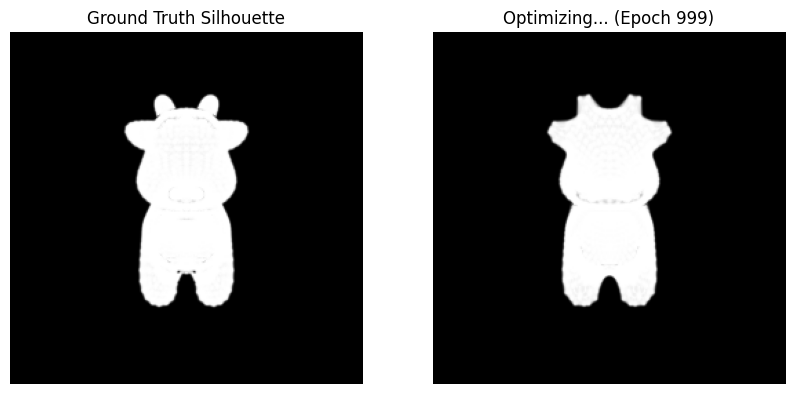

优化完成！所有中间状态的 .obj 文件已保存在 output_meshes 文件夹中。


In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
# 引入 save_obj 用于保存 3D 模型
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer, SoftSilhouetteShader, BlendParams
)


# 确认设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")
print(f"PyTorch3D 版本: {pytorch3d.__version__}")

# 1. 直接读取本地模型文件
obj_path = "cow.obj" 
if not os.path.exists(obj_path):
    raise FileNotFoundError("未找到 cow.obj，请确保代码文件与 obj 文件在同一目录下！")

verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0]) 
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])

# 2. 渲染管线与摄像机配置
num_views = 20
cameras = FoVPerspectiveCameras(device=device, 
                                R=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[0], 
                                T=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[1])

rasterizer = MeshRasterizer(cameras=cameras, 
                            raster_settings=RasterizationSettings(image_size=256, blur_radius=np.log(1./1e-4 - 1.)*1e-4, faces_per_pixel=50))
shader = SoftSilhouetteShader(blend_params=BlendParams(sigma=1e-4, gamma=1e-4))

target_silhouette = shader(rasterizer(cow_mesh.extend(num_views)), cow_mesh.extend(num_views))[..., 3]

# 3. 优化器初始化：从圆球开始
src_mesh = ico_sphere(4, device)
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)
optimizer = torch.optim.SGD([deform_verts], lr=1.0, momentum=0.9)

# 创建保存中间结果的文件夹
output_dir = "output_meshes"
os.makedirs(output_dir, exist_ok=True)
print(f"中间模型将保存在目录: ./{output_dir}/")

# 4. 可微渲染优化循环
epochs = 1000 # 增加迭代次数为 1000 次
for i in range(epochs):
    optimizer.zero_grad()
    
    # 依据当前计算出的偏移量，形变生成新的 Mesh
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 渲染当前 Mesh 的 20 个视角剪影
    pred_silhouette = shader(rasterizer(new_src_mesh.extend(num_views)), new_src_mesh.extend(num_views))[..., 3]
    
    # 核心损失：均方误差 + 三大正则化惩罚
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()

    # 调整参数：1.0 0.1 0.01 -> 1.0 1.0 0.1
    loss = loss_silhouette + \
           1.0 * mesh_laplacian_smoothing(new_src_mesh) + \
           1.0 * mesh_edge_loss(new_src_mesh) + \
           0.1 * mesh_normal_consistency(new_src_mesh)
    
    loss.backward()
    optimizer.step()

    # 可视化与模型保存逻辑：每 20 步执行一次
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        print(f"迭代步数: {i:03d}/{epochs} | 总 Loss: {loss.item():.4f} | 剪影误差: {loss_silhouette.item():.4f}")
        
        # 提取当前网格的顶点和面，并保存为 .obj 文件
        # verts_list()[0] 和 faces_list()[0] 用于获取 batch 中第一个网格的数据
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"[*] 已保存当前 3D 模型至: {save_path}")
        
        # 刷新对比图
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        
        ax[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
        ax[0].set_title("Ground Truth Silhouette")
        ax[0].axis("off")
        
        ax[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
        ax[1].set_title(f"Optimizing... (Epoch {i})")
        ax[1].axis("off")
        
        plt.show()

print(f"优化完成！所有中间状态的 .obj 文件已保存在 {output_dir} 文件夹中。")

迭代步数: 999/1000 | 总Loss: 0.0191 | 剪影Loss: 0.0018 | RGB Loss: 0.0081


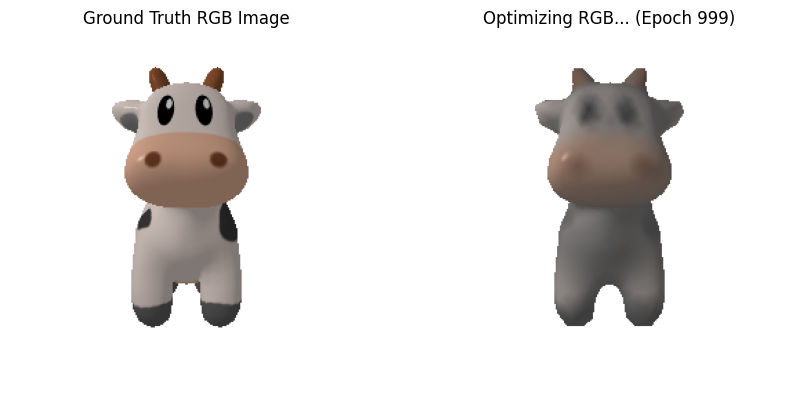

优化完成！所有中间状态的文件已保存在 output_textured_meshes 文件夹中。


In [16]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
from pytorch3d.io import load_objs_as_meshes, save_ply
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency

from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer, MeshRenderer,
    SoftSilhouetteShader, SoftPhongShader, PointLights, TexturesVertex, BlendParams
)

def save_colored_ply(filepath, verts, faces, colors):
    """
    强制保存带有 RGB 顶点颜色的 .ply 文件
    verts: 顶点坐标 Tensor (V, 3)
    faces: 面片索引 Tensor (F, 3)
    colors: 顶点颜色 Tensor (V, 3)，取值范围 0~1
    """
    verts_np = verts.detach().cpu().numpy()
    faces_np = faces.detach().cpu().numpy()
    # 将颜色从 0~1 转换为 0~255 的整数
    colors_np = (colors.detach().cpu().numpy() * 255).astype(np.uint8)
    
    with open(filepath, 'w') as f:
        # 写入 PLY 标准文件头
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {len(verts_np)}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\n")
        f.write(f"element face {len(faces_np)}\n")
        f.write("property list uchar int vertex_indices\n")
        f.write("end_header\n")
        
        # 写入 顶点坐标 + 顶点颜色
        for i in range(len(verts_np)):
            v = verts_np[i]
            c = colors_np[i]
            f.write(f"{v[0]} {v[1]} {v[2]} {c[0]} {c[1]} {c[2]}\n")
            
        # 写入 面片索引
        for i in range(len(faces_np)):
            face = faces_np[i]
            f.write(f"3 {face[0]} {face[1]} {face[2]}\n")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")

# 加载包含纹理的目标模型
obj_path = "cow.obj" 
if not os.path.exists(obj_path):
    raise FileNotFoundError("未找到 cow.obj，请确保代码文件与 obj 文件及其纹理图片(如果有)在同一目录下！")

# 使用 load_objs_as_meshes 解析材质和纹理
cow_mesh = load_objs_as_meshes([obj_path], device=device)

# 归一化网格大小和中心
verts = cow_mesh.verts_packed()
center = verts.mean(0)
scale = max((verts - center).abs().max(0)[0])
cow_mesh.offset_verts_(-center)
cow_mesh.scale_verts_((1.0 / float(scale)))

# 渲染管线与摄像机、光照配置
num_views = 20
R, T = look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))
cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

# 加入点光源
lights = PointLights(device=device, location=[[2.0, 2.0, -2.0]])

# 剪影渲染器用于监督形状
raster_settings_sil = RasterizationSettings(
    image_size=256, blur_radius=np.log(1./1e-4 - 1.)*1e-4, faces_per_pixel=50
)
silhouette_renderer = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings_sil),
    shader=SoftSilhouetteShader(blend_params=BlendParams(sigma=1e-4, gamma=1e-4))
)

# Phong渲染器用于监督 RGB 纹理
raster_settings_rgb = RasterizationSettings(
    image_size=256, blur_radius=0.0, faces_per_pixel=1
)
phong_renderer = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings_rgb),
    shader=SoftPhongShader(device=device, cameras=cameras, lights=lights)
)

# 预先生成 Ground Truth 的剪影和 RGB 图像
target_silhouette = silhouette_renderer(cow_mesh.extend(num_views))[..., 3]
target_rgb = phong_renderer(cow_mesh.extend(num_views))[..., :3]

# 优化器初始化：形状坐标 + 顶点颜色
src_mesh = ico_sphere(4, device)
verts_shape = src_mesh.verts_packed().shape

# 待优化参数 1：顶点坐标的形变偏移量
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)

# 待优化参数 2：源网格的顶点颜色，初始统一设为灰色(0.5)
sphere_verts_rgb = torch.full([1, verts_shape[0], 3], 0.5, device=device, requires_grad=True)

# 将形状参数和颜色参数共同放入优化器
optimizer = torch.optim.SGD([deform_verts, sphere_verts_rgb], lr=1.0, momentum=0.9)

output_dir = "output_textured_meshes"
os.makedirs(output_dir, exist_ok=True)

# 联合优化循环
epochs = 1000 
for i in range(epochs):
    optimizer.zero_grad()
    
    # 依据当前计算出的偏移量，形变生成新的 Mesh
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 将当前优化的颜色赋值给新的 Mesh
    new_src_mesh.textures = TexturesVertex(verts_features=torch.clamp(sphere_verts_rgb, 0.0, 1.0))
    
    # 分别渲染当前 Mesh 的 20 个视角的剪影和 RGB 图像
    pred_silhouette = silhouette_renderer(new_src_mesh.extend(num_views))[..., 3]
    pred_rgb = phong_renderer(new_src_mesh.extend(num_views))[..., :3]
    
    # 损失计算
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()
    loss_rgb = ((pred_rgb - target_rgb) ** 2).mean() # 纹理损失

    # 总 Loss = 剪影形状误差 + RGB颜色误差 + 网格平滑正则化
    loss = loss_silhouette + loss_rgb + \
           1.0 * mesh_laplacian_smoothing(new_src_mesh) + \
           1.0 * mesh_edge_loss(new_src_mesh) + \
           0.1 * mesh_normal_consistency(new_src_mesh)
    
    loss.backward()
    optimizer.step()

    # 可视化监控
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        print(f"迭代步数: {i:03d}/{epochs} | 总Loss: {loss.item():.4f} | 剪影Loss: {loss_silhouette.item():.4f} | RGB Loss: {loss_rgb.item():.4f}")
        
        # ----------------- 保存彩色 PLY -----------------
        eval_mesh = new_src_mesh.clone()
        eval_mesh.textures = TexturesVertex(verts_features=torch.clamp(sphere_verts_rgb, 0.0, 1.0))
        
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.ply")
        
        from pytorch3d.io import IO
        # 提取当前网格的顶点和面
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        
        # 提取当前优化的颜色并限制在 0~1 之间
        current_colors = torch.clamp(sphere_verts_rgb[0], 0.0, 1.0)
        
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.ply")
        
        # 调用函数，强制把颜色写进去
        save_colored_ply(save_path, current_verts, current_faces, current_colors)
        
        # 刷新对比图
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        
        # Target RGB
        ax[0].imshow(target_rgb[0].cpu().numpy())
        ax[0].set_title("Ground Truth RGB Image")
        ax[0].axis("off")
        
        # Predicted RGB
        ax[1].imshow(pred_rgb[0].detach().cpu().numpy())
        ax[1].set_title(f"Optimizing RGB... (Epoch {i})")
        ax[1].axis("off")
        
        plt.show()

print(f"优化完成！所有中间状态的文件已保存在 {output_dir} 文件夹中。")